# Práctica OCR: Extracción de texto

En este notebook practicaremos tres enfoques fundamentales de OCR (Optical Character Recognition):
1. **OCR Clásico con Tesseract**: Aprenderemos la importancia del preprocesado.
2. **OCR Moderno con PaddleOCR**: Uso de modelos robustos para escenas reales.
3. **Pipeline YOLO + OCR**: El flujo completo de detección y reconocimiento.
4. **Postprocesado**: Uso de Regex para limpiar datos.

---

In [ ]:
!sudo apt-get install tesseract-ocr tesseract-ocr-spa -y
!pip install pytesseract "paddleocr<3" "paddlepaddle<3" opencv-python ultralytics

In [2]:
import cv2
import pytesseract
import matplotlib.pyplot as plt
import numpy as np
from paddleocr import PaddleOCR
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from IPython.display import clear_output
import requests
import re
from PIL import Image
from io import BytesIO
from yt_dlp import YoutubeDL

def download_img(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    return cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

def show_img(img, title="Imagen"):
    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

## Preprocesado en OCR

Los motores de OCR (especialmente los clásicos como Tesseract) funcionan mejor cuando el texto es **negro puro sobre fondo blanco puro**, sin ruido ni sombras.

### Técnicas:
1. **Escala de Grises**: Simplifica la imagen eliminando el color.
2. **Denoising (Filtros)**: Elimina el "granulado" o manchas del papel.
3. **Thresholding (Umbralizado)**: Convierte la imagen a blanco y negro (binaria).

### Preprocesado común:
```python
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Filtro para suavizar y quitar ruido
blur = cv2.GaussianBlur(gray, (5, 5), 0)
# Binarización de Otsu (calcula el umbral automáticamente)
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
```

El preprocesado a usar depende de la imagen, hay que pensar:
 - ¿Me ayudará usar escala de grises?
 - ¿El texto es fino o tiene ruido para suavizarlo?
 - ¿El fondo es uniforme o complejo?

# Ejercicio 1: Tesseract y preprocesado

Intentaremos leer un DNI. Verás que sin preprocesado los resultados pueden ser desastrosos.

## Qué hay que hacer:
1. Descargar la imagen del DNI.
2. Intentar pasar Tesseract directamente y observar el resultado.
3. Diseña y prueba 2 preprocesados distintos, por ejemplo:
    - Escala de grises
    - Escala de grises + blur
    - Escala de grises + threshold    
4. Prueba distintos valores de `--psm` según cómo creas que es la imagen:
    - 6  (si hay muchos bloques de texto)
    - 7  (si hay una sola línea de texto)
    - 8  (si hay palabras sueltas)
    - 11 (si hay texto muy disperso sin estructura)
5. Comprueba qué configuraciones obtienen mejor el nombre y el número de DNI

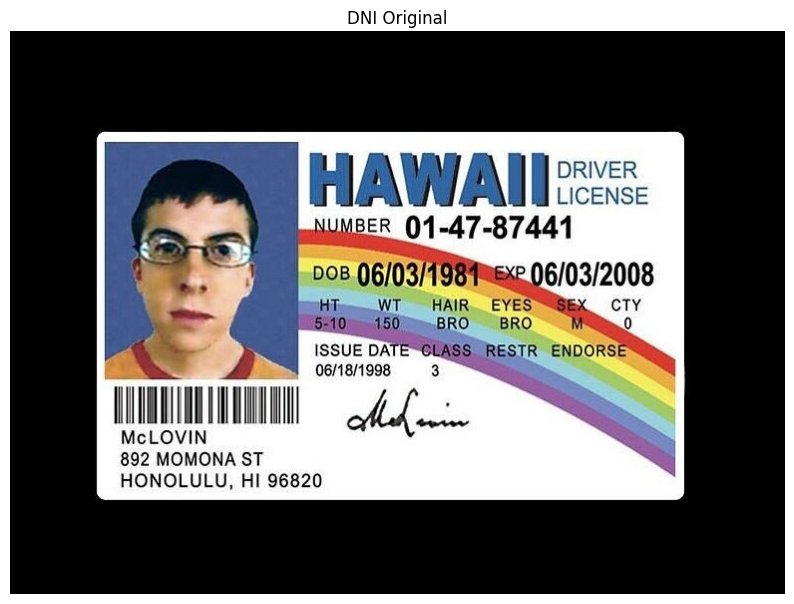

In [3]:
#Imagen del DNI
IMG_URL = "https://raw.githubusercontent.com/jorgecs/apuntes/main/docs/ut5_ia_aplicada/4_yolo/img/dni.jpg" 
img_dni = download_img(IMG_URL)
show_img(img_dni, "DNI Original")

In [ ]:
#TODO: OCR directo


#TODO: Preprocesado (Grayscale -> Blur -> Threshold ...)

#TODO: Muestra la imagen preprocesada

#TODO: OCR tras preprocesado

# Ejercicio 2: PaddleOCR - OCR en escenas reales

PaddleOCR es mucho más potente para detectar texto inclinado o con fondos complejos.

## Qué hay que hacer:
1. Inicializar el modelo de PaddleOCR (idioma español).
2. Descargar una imagen de un cartel en la calle.
3. Procesar la imagen con PaddleOCR.
4. Extraer los resultados e imprimir: texto y confianza. `bbox, (text, conf) = line`

In [ ]:
#TODO: Inicializa PaddleOCR

#TODO: Busca una imagen de un cartel
SCENE_URL = ""
img_scene = download_img(SCENE_URL)

show_img(img_scene, "Imagen de Escena")

In [ ]:
#TODO: Procesa la imagen y visualiza resultados

# Ejercicio 3: Pipeline YOLO + OCR

Flujo en aplicaciones profesionales: Detectar -> Recortar -> Reconocer. En este ejercicio se detectará cuando una jugadora de baloncesto hace campo atrás y se mostrará al final cuál ha sido esa jugadora.
Se recomienda usar GPU en YOLO.

In [ ]:
YT_VIDEO_URL = "https://www.youtube.com/watch?v=eoqMEzgKR6M"

ydl_opts = {
    "format": "bv*[vcodec^=avc1]+ba/b[ext=mp4]",
    "outtmpl": "/content/full_video.%(ext)s",
    "merge_output_format": "mp4",
}


with YoutubeDL(ydl_opts) as ydl:
    ydl.download([YT_VIDEO_URL])

VIDEO_PATH = "/content/basketball.mp4"

In [ ]:
!ffmpeg -ss 02:53 -to 03:00 -i /content/full_video.mp4 -c copy /content/basketball.mp4 -y

**Qué hay que hacer:**

- Crea un ROI, las coordenadas serán X1:0 X2:1900 Y1:320 Y2:900 y solo se procesarán las detecciones cuyo centro del bounding box esté dentro del ROI
  - `cx = (x1+x2)/2`
  - `cy=(y1+y2)/2`
- Crea una línea vertical, estará en X:1650
- Guarda los `track_id` para identificar a las jugadoras a lo largo del vídeo
- Guarda la posición de cada jugadora en cada frame:
  - Para cada `track_id`, almacena su posición horizontal
  - Se puede guardar `cx` o `x2`, aunque se recomienda `x2` porque la cámara se mueve.
- Además, en cada frame, guarda el recorte de cada jugadora:
    - Recorta el frame: `crop = frame[int(y1):int(y2), int(x1):int(x2)]`
    - Almacena los recortes de cada jugadora en cada frame: `crops_por_id[track_id].append(crop)` (igual que como se ha hecho para guardar `track_id`)  
- Detectar cuando una jugadora atraviesa la línea de izquierda a derecha:
  - Se compara la posición del mismo `track_id` entre frames.
  - Hay que obtener la posición horizontal de este frame y del anterior:
    - `frame_anterior = trayectorias[track_id][-2]`
    - `frame_actual = trayectorias[track_id][-1]`
  - La condición es que `frame_anterior < X and frame_actual >= X`. 
  - Se puede usar `cx` o `x2` para la condición, aunque se recomienda `x2` porque la cámara se mueve.
- Cuando una jugadora cruce la línea:
    - Coger todos los crops de ese track_id `for crop in crops_por_id[track_id]: ` 
    - Aplicar OCR a todos los crops 
    - Guardarlo en un array `dorsales_por_crop`
- Como el OCR puede no funcionar correctamente con solo una imagen, hay que escoger el valor de dorsal más veces encontrado, por tanto, al final se calcula la moda (siguiente celda)

In [ ]:
#TODO: Usa tracking de YOLO para el vídeo y haz OCR de cada frame cuando una jugadora pase la línea
model = YOLO("yolov8m.pt")
cap = cv2.VideoCapture(VIDEO_PATH)

ROI_X1, ROI_Y1 = 0, 320 #Borde izquierdo ROI
ROI_X2, ROI_Y2 = 1900 , 900 #Borde derecho ROI

LINE_X = 1650 #Para la línea

contador = 0 #Para contar cada vez que una jugadora pase, se puede mostrar en vídeo
contados = set() #Para almacenar los track_id de las jugadoras que pasen la línea

trayectorias = {} #Para almacenar x2 o cx de cada jugadora y poder comprobar los frames anteriores

crops_por_id = {} #Para almacenar los recortes de cada jugadora en cada frame y así tenerlos disponibles por si esa jugadora pasa la línea

dorsales_por_crop=[] #Para almacenar los resultados del OCR de los recortes de una jugadora una vez haya cruzado la línea




In [ ]:
from collections import Counter

dorsal_final = Counter(dorsales_por_crop).most_common(1)[0][0]
print(dorsal_final)

# Ejercicio 4: Postprocesado (OCR + Regex)

Usaremos Regex para extraer solo los datos que nos importan de una cadena de texto sucia. Vamos a usar como base el DNI del ejercicio 1

## ¿Qué es Regex?
Regex (expresiones regulares) es una forma de buscar patrones dentro de texto. En vez de buscar palabras exactas, buscas estructuras.

Ejemplo:
- fechas
- números de DNI
- códigos
- nombres en mayúsculas

1. Buscar números:
    ```
    \d+
    ```
    Encuentra cualquier número, con cualquier cantidad de dígitos
     - `\d` → cualquier dígito (0-9)
     - `+` → uno o más
    ```
    12345 → ✔
    ```

2. Buscar fecha (formato DD/MM/AAAA):
    ```
    \d{2}/\d{2}/\d{4}
    ```
    Encuentra una fecha con 2_digitos/2digitos/4_digitos
     - `{2}` → exactamente 2 dígitos
     - `{4}` → exactamente 4 dígitos
    ```
    06/03/2008 → ✔
    ```

3. Buscar DNI (8 números y una letra):
    ```
    \d{8}[A-Z]
    ```
    Encuentra DNI:
     - [A-Z] → letra mayúscula
    ```
    12345678Z → ✔
    ```

4. Buscar palabras alternando mayúscula y minúscula
    ```
    [A-Z][a-zA-Z]{2,}
    ```
    Encuentra palabras que empiecen por mayúscula y sigan con letras tanto mayúsculas como minúsculas, con al menos 2 letras
     - [a-z] → letra minúscula
     - [a-zA-Z] → cualquier combinación de letras minúsculas y mayúsculas
     - {2,} → al menos dos letras. Delimita la cantidad, el primer valor es el mínimo y el segundo es el máximo
    ```
    John → ✔
    ```

5. Buscar palabras exactas y espacios
    ```
    \d{3}\s+[A-Z\s]+AVENIDA
    ``` 
    Encuentra palabras acabadas en AVENIDA con espacios variables entre medias
     - \s → espacio entre lo anterior y lo siguiente
     - \s+ → uno o más espacios
     - AVENIDA → que aparezca exactamente AVENIDA
    ```
    123  NUESTRA   PRIMERA   AVENIDA → ✔
    ```


En Python se usan con la librería Regex
```python
import re

text = ...

números = re.findall(r"\d+", text)

fechas = re.findall(r"\d{2}/\d{2}/\d{4}", text)

dni = re.findall(r"\d{8}[A-Z]", text)

nombres = re.findall(r"[A-Z][a-zA-Z]{2,}", text)

direccion = re.findall(r"\d{3}\s+[A-Z\s]+AVENIDA", text)
```

## Qué hay que hacer:
1. Toma el texto sucio que te devolvió el OCR.
2. Usando regex, obtén lo suguiente del texto sucio de TesseractOCR
    - Busca el número del documento
    - Identifica la dirección
    - Encuentra el nombre

Si algún campo no te lo ha detectado bien el OCR, prueba con otros, como la fecha de nacimiento   


In [ ]:
#TODO: Extrae número de documento, fecha de nacimiento y nombre usando Regex sobre el texto obtenido tras el preprocesado y aplicar Tesseract del ejercicio 1

# Ejercicio 5: Fallback de OCR
Una práctica común en entornos profesionales es utilizar varios modelos de OCR, si el rápido y principal devuelve un resultado con poca confianza, realizar el OCR con un modelo más pesado.

**Qué hay que hacer:**
- Completa la función de fallback, el primero modelo será TesseractOCR
- Si da una confianza por debajo del umbral (20%), usar en su lugar PaddleOCR

En TesseractOCR, para obtener la confianza, usamos `pytesseract.image_to_data(image, output_type=pytesseract.Output.DICT)`, que nos devuelve boxes, confianza, líneas, números de página...
Podemos filtrar con `["conf"]` para obtener solo la confianza.
Esto devuelve una lista con la confianza para cada trozo de texto, normalmente se trabaja con la media de todos los textos.

In [ ]:
def fallback_ocr(image, umbral=30):

    #TODO: empieza usando Tesseract con configuración básica, obtén el texto y también la confianza

    if ... < umbral:
        #TODO: si la media de confianza del texto es menor que el umbral, haz un preprocesado más agresivo utilizando PaddleOCR


    return ...


print(fallback_ocr(img_dni))
